In [1]:
import os
import pandas as pd
import sys
##################
## 경로 
# coreCodePath=r"D:\pyWInSite\core"                ## core 폴더가 들어있는 상위경로
# sys.path.append(coreCodePath)
# coreCodePath=r"D:\EM_KDH\pyWInsite\pyWInsite\core"                ## core 폴더가 들어있는 상위경로
coreCodePath=r"D:\Code_Rep\pyWInsite\core"
sys.path.append(coreCodePath)

In [2]:
from getFileList import getFileList
allP2mFiles=getFileList(r"D:\Code_Rep\pyWInsite\filtered_p2m_files",'p2m')

from filterListByString import filterListByString
powerP2m=filterListByString(allP2mFiles,'.power.')

## 주파수 리스트 추출
## Result Folder List 추출
## 각도별 > Result Folder for each port

In [3]:
RxList = [item.split('.')[-2] for item in powerP2m if '.' in item]
len(RxList)
unique_RxList = list(set(RxList))

In [4]:
from mkDataFrameFromP2mFile import makeDataFrameFromP2mFile
dataFrames = [makeDataFrameFromP2mFile(filePath) for filePath in powerP2m]
allPortDatas=pd.concat(dataFrames, ignore_index=True)
groupedByPort = allPortDatas.groupby("PortNumber")


In [5]:
# xticklabel을 변환하는 함수
def customXticklabels():
    labels = []
    for t in range(0, 360, 30):
        if t <= 180:
            labels.append(f"{t}°")  # 0~180은 그대로
        else:
            labels.append(f"{t-360}°")  # 180~330은 음수 변환 (-180 ~ -30)
    return labels

C:\Users\dhkang\AppData\Local\Temp\ipykernel_18968\4236159046.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.3))


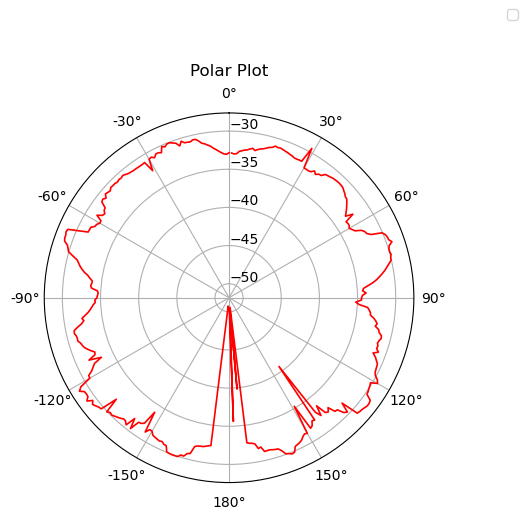

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# DataFrame을 입력으로 받아서 Polar Plot을 그리는 함수
def plotPolarFromDataFrame(DataFrame):
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    
    Deg = DataFrame.filter(like='Deg', axis=1)
    radius = DataFrame.filter(like='Power', axis=1)

    if len(Deg.columns) != len(radius.columns):
        print('The number of columns of Deg and Power should be the same')
        return
    else:
        theta = np.radians(Deg)
        ax.plot(theta, radius,color='red',linewidth=1.2)
        
        ax.set_title("Polar Plot", va='bottom')
        ax.set_theta_zero_location('N')  # 0도를 북쪽(12시 방향)으로 설정
        ax.set_theta_direction(-1)  # 시계방향으로 설정
        
        # 주요 X축(각도) 눈금 (30도 간격)
        major_ticks = np.radians(range(0, 360, 30))
        ax.set_xticks(major_ticks)
        ax.set_xticklabels(customXticklabels())
        # ax.set_xticklabels([f"{t}°" for t in range(0, 360, 30)])  # 각도 라벨 추가
        ax.set_rlabel_position(0)  # y축(r 값) tick label을 12시 방향에 정렬

        # ✅ 작은 θ축 눈금 (6도 간격으로 설정, 30도 사이에 5개 추가)
        # minor_ticks = np.radians(range(0, 360, 6))  # 6도 간격으로 작은 눈금 추가
        # ax.set_xticks(minor_ticks, minor=True)
        # ✅ 바깥쪽 원에 작은 tick 선 표시
        # ax.tick_params(axis='x', which='minor', length=5, width=1, color='black')
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.3))
        plt.show()
        fig.tight_layout()

plotPolarFromDataFrame(groupedByPort.get_group(1))  # 기존 함수 호출하여 개별 플롯 추가


In [45]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Plotly를 사용하여 Polar Plot을 그리는 함수
def plotPolarFromDataFramePlotly(DataFrame):
    Deg = DataFrame.filter(like='Deg', axis=1).values.flatten()
    radius = DataFrame.filter(like='Power', axis=1).values.flatten()
    fig = go.Figure()

    fig.add_trace(go.Scatterpolar(
        r=radius,
        theta=Deg,
        mode='lines',
        line=dict(color='red'),
        name='Polar Plot'
    ))

    # ✅ Tick 및 Grid 설정
    fig.update_layout(
        polar=dict(
            angularaxis=dict(
                tickmode='array',
                tickvals=list(range(0, 360, 30)),  # 30도 간격 major tick
                ticktext=customXticklabels(),  # customXticklabels 함수 적용
                tickfont=dict(size=16,  family='Aeonik Pro',color="black"),
                direction="clockwise",  # 시계방향 설정
                rotation=90,  # 시작 축을 12시 방향으로 설정
                showgrid=True,  # Grid 표시
                gridcolor="lightgray",  # Grid 색상 설정
                gridwidth=2,  # Grid 선 두께 설정
                linecolor="black",  # 축 선 색상을 검은색으로 설정
                layer="below traces",  # 기본 그리드 아래에 배치
            ),
            radialaxis=dict(
                showgrid=True,
                gridcolor="lightgray",  # 기본 Grid 색상 설정
                gridwidth=2,  # 기본 Grid 선 두께 설정
                tickfont=dict(size=16, family='Aeonik Pro',color="black"),
                range=[-50,-22],
                tickangle=90,  # Radial tick labels parallel to x-axis
                showline=False,
                angle=90,  # Radial ticks 방향을 12시로 설정
                griddash="dot",  # Grid 선 종류를 점선으로 설정
                
            ),
        ),
        # margin=dict(l=0, r=0, t=50, b=100),  # 좌우(l, r) 여백을 줄이고, 상하(t, b)도 조정
        showlegend=True,
        legend=dict(
            x=0.5,  # X축 가운데 정렬
            y=-0.1,  # ✅ 아래쪽으로 이동 (기본값은 1.0)
            xanchor="center",  # 가운데 정렬
            yanchor="top" , # 위쪽을 기준으로 내리기
            font=dict(size=16, family='Aeonik Pro',color="black"),  # 폰트 크기 및 색상 설정 
        ),
    )     
    # fig.update_layout(autosize=True)
    fig.update_layout(width=700, height=700)
   
    fig.show()  # Display the plot

    return fig

In [46]:
fig=plotPolarFromDataFramePlotly(groupedByPort.get_group(1))

import plotly.io as pio

# SVG 형식으로 저장
# pio.write_image(fig, "polar_plot.svg", format="svg")


In [ ]:
def plotMultiplePolarUsingFunction(dataFrames):
    """
    plotPolarFromDataFrame을 여러 번 호출하여 여러 DataFrame을 하나의 Polar Plot에 겹쳐서 그리는 함수.
    
    :param dataFrames: 리스트 형태의 DataFrame들
    """
    import matplotlib.pyplot as plt
    from plotPolarFromDataFrame import plotPolarFromDataFrame

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})  # 빈 Polar Plot 생성
    
    for df in dataFrames:
        plotPolarFromDataFrame(df)  # 기존 함수 호출하여 개별 플롯 추가

    plt.show()


In [ ]:
ListdataFrames = [groupedByPort.get_group(port) for port in [0, 1, 2] if port in groupedByPort.groups]

In [ ]:
plotMultiplePolarUsingFunction(ListdataFrames)